## Japan Cherry Blossom Forecast ##
Below, is a preliminary exploratory analysis of Japanese Cherry Blossom Forecast for 2024. The purpose of this demonstration, is to learn how to connect a Git-Hub repo to a Jupyter Notebook and do some basic exploratory analysis with the data. The business question is associated with the Japan branch on an international tourism company that arranges tours and specialized offerings. By far, the most popular offering is a tour for Cherry Blossom season. They have recently processed and translated 2024 cherry blossom forecast data from NHK and are hoping to utilize this information in selecting the order and location of potential itinerary offerings for tour groups based upon when the cherry blossoms are likely to peak in a given area, capacity (as measured in the number of viewing sites), along with the temperature and precipitation forecast for an ideal experience.

Step #1: We begin by importing the relevant libraries:

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from urllib.request import urlopen
import ssl
import seaborn as sns
import plotly.express as px
from datetime import datetime
import plotly.figure_factory as ff
import kaleido
import folium
import plotly
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Let's begin by downloading the "Cherry_Blossom_Forecasts.csv" file from the GitHub repository using the urlopen function.

ssl_context = ssl._create_unverified_context()
url1 = "https://raw.githubusercontent.com/homdch/Japan-Cherry-Blossom-Forecast/refs/heads/main/Cherry_Blossom_Forecasts.csv"

# Pass the opened handle directly to read_csv
with urlopen(url1, context=ssl_context) as response:
    df1 = pd.read_csv(response)

In [3]:
#Next, let's do the same for the "Cherry_Blossom_Places.csv" file.

ssl_context = ssl._create_unverified_context()
url2 = "https://raw.githubusercontent.com/homdch/Japan-Cherry-Blossom-Forecast/refs/heads/main/Cherry_Blossom_Places.csv"

# Pass the opened handle directly to read_csv
with urlopen(url2, context=ssl_context) as response:
    df2 = pd.read_csv(response)

Step #2: Let's continue by conducting an exploratory analysis of the data, looking at the first 5 entries of each entity.

In [4]:
print("Cherry Blossom Forecasts:")
print(df1.head(5))
print("Cherry Blossom Places:")
print(df2.head(5))

Cherry Blossom Forecasts:
   place_code    date mankai_date kaika_date  meter      ft  tavg  tmin  tmax  \
0     1370053  2/1/24     5/12/24     5/7/24     12  3.6576  -7.8 -11.4  -5.3   
1     1370022  2/1/24      5/3/24    4/29/24     12  3.6576  -4.2  -7.6   0.5   
2     1370024  2/1/24      5/9/24     5/4/24     10  3.0480  -4.2  -7.6   0.5   
3     1370028  2/1/24     5/10/24     5/4/24     13  3.9624  -5.6  -6.8  -4.5   
4     1370029  2/1/24      5/9/24     5/6/24     13  3.9624   NaN   NaN   NaN   

   tavg_f  tmin_f  tmax_f  prcp    pcp_in  
0   17.96   11.48   22.46   4.1  0.161417  
1   24.44   18.32   32.90   0.3  0.011811  
2   24.44   18.32   32.90   0.3  0.011811  
3   21.92   19.76   23.90   0.0  0.000000  
4   32.00   32.00   32.00   NaN  0.000000  
Cherry Blossom Places:
        prefecture                         spot_name        lat         lon  \
0  Hokkaido Island       Higashimei Park, Bibai City  43.340985  141.895581   
1  Hokkaido Island                    Gory

#### Context: ####

Date: Pertains the the date at which the estimate for cherry blossom season prediction was recorded for a particular location.

Kaika Dates: Pertains to the start of flowering for cherry blossom season.

Mankai Dates: This marks full bloom for cherry blossoms.

Cherry blossom peak full bloom (mankai) typically lasts for about 5-7 days (up to a week) before the petals begin
to fall off. For the purpose of estimating the cherry blossom end date, we will assume that the end of
blossoming for a particular area occurs roughly a week after the Mankai dates. We will add a column for the estimated end date to the data frame
for Cherry Blossoms Forecasts.


In [5]:
#Reformats the date data#
df1['date'] = pd.to_datetime(df1['date'])
df1['kaika_date'] = pd.to_datetime(df1['kaika_date'])
df1['mankai_date'] = pd.to_datetime(df1['mankai_date'])
#Calculates the estimated end date for a particular area #
df1['estimated_end_date'] = df1['mankai_date'] + pd.Timedelta(weeks=1)
df1.head(5)

,place_code,date,mankai_date,kaika_date,meter,ft,tavg,tmin,tmax,tavg_f,tmin_f,tmax_f,prcp,pcp_in,estimated_end_date
0,1370053,2024-02-01,2024-05-12,2024-05-07,12,3.6576,-7.8,-11.4,-5.3,17.96,11.48,22.46,4.1,0.161417,2024-05-19
1,1370022,2024-02-01,2024-05-03,2024-04-29,12,3.6576,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,2024-05-10
2,1370024,2024-02-01,2024-05-09,2024-05-04,10,3.0480,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,2024-05-16
3,1370028,2024-02-01,2024-05-10,2024-05-04,13,3.9624,-5.6,-6.8,-4.5,21.92,19.76,23.90,0.0,0.000000,2024-05-17
4,1370029,2024-02-01,2024-05-09,2024-05-06,13,3.9624,NaN,NaN,NaN,32.00,32.00,32.00,NaN,0.000000,2024-05-16


Next, let's calculate the estimated number of days of cherry blossom season, this will be accomplished by subtracting the kaika_date
from the end date.

In [6]:
#we can also rearrange the columns to have it make more sense.#
df1['duration'] = df1['estimated_end_date'] - df1['kaika_date']
desired_order = ['place_code', 'date', 'kaika_date', 'mankai_date', 'estimated_end_date', 'duration',
                 'meter','ft','tavg','tmin','tmax','tavg_f','tmin_f','tmax_f','prcp','pcp_in']
df1 = df1.reindex(columns=desired_order)
df1.head(5)

,place_code,date,kaika_date,mankai_date,estimated_end_date,duration,meter,ft,tavg,tmin,tmax,tavg_f,tmin_f,tmax_f,prcp,pcp_in
0,1370053,2024-02-01,2024-05-07,2024-05-12,2024-05-19,12 days,12,3.6576,-7.8,-11.4,-5.3,17.96,11.48,22.46,4.1,0.161417
1,1370022,2024-02-01,2024-04-29,2024-05-03,2024-05-10,11 days,12,3.6576,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811
2,1370024,2024-02-01,2024-05-04,2024-05-09,2024-05-16,12 days,10,3.0480,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811
3,1370028,2024-02-01,2024-05-04,2024-05-10,2024-05-17,13 days,13,3.9624,-5.6,-6.8,-4.5,21.92,19.76,23.90,0.0,0.000000
4,1370029,2024-02-01,2024-05-06,2024-05-09,2024-05-16,10 days,13,3.9624,NaN,NaN,NaN,32.00,32.00,32.00,NaN,0.000000


Now that we have calculated the necessary information, we can now create some data visualizations for a preliminary analysis. We can begin by incorporating the geographic data.
This information can be used to create a map plot with the kaika, mankai, and estimated end dates to determine when cherry blossom season is likely to begin and peak for each site.

In [7]:
# We can begin by merging the two dataframes together on place_code, in a dataframe called df_merged. This merged data can form the basis of our mapping information.#

df_merged = df1.merge(df2, left_on='place_code', right_on='code')
del df_merged['code']

df_merged.head()

,place_code,date,kaika_date,mankai_date,estimated_end_date,duration,meter,ft,tavg,tmin,tmax,tavg_f,tmin_f,tmax_f,prcp,pcp_in,prefecture,spot_name,lat,lon
0,1370053,2024-02-01,2024-05-07,2024-05-12,2024-05-19,12 days,12,3.6576,-7.8,-11.4,-5.3,17.96,11.48,22.46,4.1,0.161417,Hokkaido Island,"Higashimei Park, Bibai City",43.340985,141.895581
1,1370022,2024-02-01,2024-04-29,2024-05-03,2024-05-10,11 days,12,3.6576,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,Hokkaido Island,Goryokaku Park,41.797090,140.755737
2,1370024,2024-02-01,2024-05-04,2024-05-09,2024-05-16,12 days,10,3.0480,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,Hokkaido Island,Aobagaoka Park,42.102654,140.575608
3,1370028,2024-02-01,2024-05-04,2024-05-10,2024-05-17,13 days,13,3.9624,-5.6,-6.8,-4.5,21.92,19.76,23.90,0.0,0.000000,Hokkaido Island,Uju Zenkoji Temple Natural Park,42.522993,140.780671
4,1370029,2024-02-01,2024-05-06,2024-05-09,2024-05-16,10 days,13,3.9624,NaN,NaN,NaN,32.00,32.00,32.00,NaN,0.000000,Hokkaido Island,Nijukken Road Cherry Blossom Row,42.403905,142.452358


In [8]:
# Note: Kaleido is still used for static image exports (fig.write_image)
# pip install kaleido==0.2.1 plotly

def df_for_map(df_merged, date=None, last=True):
    if last:
        df_map = df_merged[df_merged['date'] == df_merged['date'].max()].copy()
    else:
        df_map = df_merged[df_merged['date'] == date].copy()
        
    # Convert to datetime first
    df_map['mankai_date'] = pd.to_datetime(df_map['mankai_date'])
    df_map['kaika_date'] = pd.to_datetime(df_map['kaika_date'])
    
    # Calculate days from today using pd.Timestamp.now() to avoid import conflicts
    current_time = pd.Timestamp.now()
    df_map['mankai_days'] = (current_time - df_map['mankai_date']).dt.days
    df_map['kaika_days'] = (current_time - df_map['kaika_date']).dt.days
    
    # Calculate estimated end date (e.g., 7 days after full bloom)
    df_map['estimated_end_date'] = df_map['mankai_date'] + pd.to_timedelta(7, unit='D')
    
    # Convert back to string for hover display
    df_map['mankai_date'] = df_map['mankai_date'].dt.strftime('%Y-%m-%d')
    df_map['kaika_date'] = df_map['kaika_date'].dt.strftime('%Y-%m-%d')
    df_map['estimated_end_date'] = df_map['estimated_end_date'].dt.strftime('%Y-%m-%d')
    
    return df_map

# --- Plotting Setup ---
METRIC = 'mankai_days'  
SAVE_IMG = True

# Assuming df_merged is defined in your environment
df_map = df_for_map(df_merged, last=True)

# Create scatter map plot 
fig = px.scatter_map(
    df_map, 
    lat='lat', 
    lon='lon', 
    color=METRIC, 
    hover_name='spot_name', 
    hover_data=['prefecture','mankai_date', 'kaika_date', 'estimated_end_date'], 
    zoom=4, 
    center={"lat": 38, "lon": 138}, 
    height=700, 
    map_style="carto-darkmatter", 
    color_continuous_scale="Pinkyl", 
    range_color=[df_map[METRIC].min(), df_map[METRIC].max()]
)

# Update layout styling
fig.update_layout(
    title=dict(
        text="🌸 Sakura Bloom Locations in Japan",
        x=0.5,  # Center the title
        xanchor='center',
        font=dict(size=20, color='black', family='Arial')
    ),
    margin=dict(r=0, t=50, l=0, b=0)
)

# Save image if flag is True
if SAVE_IMG:
    fig.write_image("sakura.png", format="png")

# --- Display in Jupyter Notebook ---
fig.show()

The most popular route for tourists in Japan is Tokyo, Osaka, and Kyoto. Most forecasts for cherry blossom season in Tokyo are roughly around the last week of March.
The same is typically true of Kyoto and Osaka; however, Cherry Blossom season tends to start later in March than in Tokyo, but continues a little bit into the first week of April.
For optimal cherry blossom viewing at the major cities, it is recommended that visitors travel during the last week of March and the first week of April, preferably starting in Tokyo and then continuing their trip to Osaka or Kyoto. For earlier cherry blossom viewing, check out Kyushu, or for later visits, check out northern Honshu and Hokkaido. Now that the map visual establishes the optimal dates for travel itineraries, we should now use the data to determine the optimal length of stay for the trip.


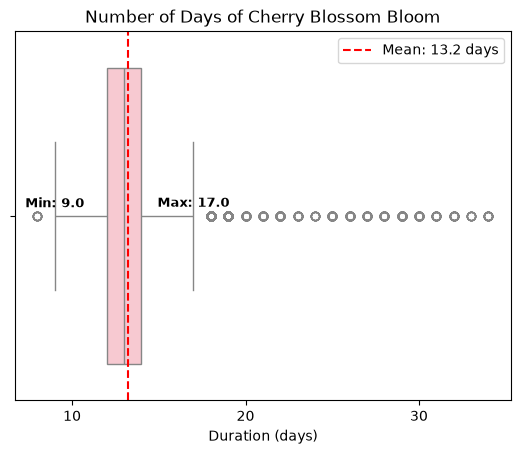

In [9]:
# Convert to numeric days first (if not done already)
df1['duration_days'] = df1['duration'].dt.days

# Calculate statistics
mean_val = df1["duration_days"].mean()
q1 = df1["duration_days"].quantile(0.25)
q3 = df1["duration_days"].quantile(0.75)
iqr = q3 - q1
lower_whisker = max(df1["duration_days"].min(), q1 - 1.5 * iqr)
upper_whisker = min(df1["duration_days"].max(), q3 + 1.5 * iqr)

# Create a horizontal boxplot
sns.boxplot(x=df1["duration_days"], color="#FFC1CC")

# Add mean line
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f} days')

# Label lower whisker
plt.text(lower_whisker, 0.55, f'Min: {lower_whisker:.1f}',
    color='black', fontsize=9, fontweight='bold',
    ha='center', va='top',
    transform=plt.gca().get_xaxis_transform())

# Label upper whisker
plt.text(upper_whisker, 0.55, f'Max: {upper_whisker:.1f}',
    color='black', fontsize=9, fontweight='bold',
    ha='center', va='top',
    transform=plt.gca().get_xaxis_transform())

# Add titles and labels
plt.title("Number of Days of Cherry Blossom Bloom")
plt.xlabel("Duration (days)")

# Scale x-axis ticks by 10
plt.xticks(np.arange(
    round(df1["duration_days"].min(), -1),
    round(df1["duration_days"].max(), -1) + 10,
    10
))
plt.legend()
plt.show()

On average, Cherry Blossom season seems to last only 13 days. If a visitor is lucky, they might be able to have a longer window. However,
it could also be a shorter window. It is recommended that they air on the side of caution and plan their trip in advance to begin no more
than 1 week after the Kaika date for chosen locations to optimize on viewing. As Cherry Blossom Season typically lasts 13 days, this time span should correspond with the ideal length of stay. However, a shorter stay of about 9 days could still be sufficient for viewing highlights or a longer stay for a more extensive itinerary.

Next, we want to know which cities/prefunctures have the most ammount of sites for viewing cherry blossoms. To accomplish this, we will create a pivot table that measures the frequency of popular cherry blossom viewing sites and then create a bar chart to select for the top 10. This is a useful measure of capacity and number of options while arranging group tours.

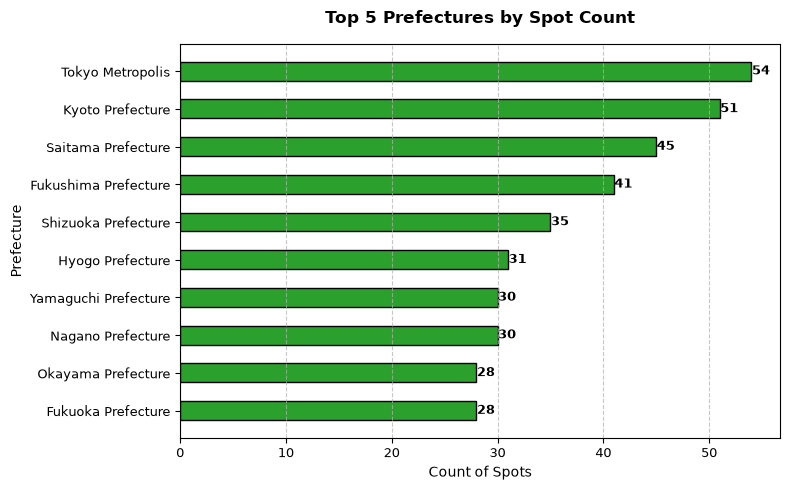

In [10]:
# 1. Create the pivot table
pivot_df = df2.pivot_table(
    index='prefecture',     
    values='spot_name',     
    aggfunc='count'         
)

# 2. Sort from greatest to lowest
pivot_df_sorted = pivot_df.sort_values(by='spot_name', ascending=False)

# 3. Reset the index
final_df = pivot_df_sorted.reset_index()

# 4. Take the first 5 entries
# We reverse the order using [::-1] so the highest value appears at the top of the horizontal chart
top_10 = final_df.head(10)[::-1]

# 5. Plot the HORIZONTAL bar chart with increased spacing
plt.figure(figsize=(8, 5))
bars = plt.barh(
    top_10['prefecture'], 
    top_10['spot_name'], 
    height=0.5,           # 'height' controls horizontal bar thickness (decreased for more space)
    color='#2ca02c', 
    edgecolor='black'
)

# 6. Add smaller exact count labels to each horizontal bar
for bar in bars:
    xval = bar.get_width()
    plt.text(
        xval + 0.05,                        # Slightly to the right of the bar end
        bar.get_y() + bar.get_height()/2, 
        int(xval), 
        ha='left', 
        va='center', 
        fontweight='bold',
        fontsize=9                          # Decreased font size for the numeric value labels
    )

# 7. Customize labels and layout with smaller fonts
plt.title('Top 5 Prefectures by Spot Count', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Count of Spots', fontsize=10)   # Decreased axis label font size
plt.ylabel('Prefecture', fontsize=10)       # Decreased axis label font size
plt.xticks(fontsize=9)                      # Decreased tick mark font size
plt.yticks(fontsize=9)                      # Decreased tick mark font size
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the chart
plt.show()

Based upon the bar chart above, it is clear that most of the Cherry Blossom viewing sites are concentrated in the central and south of Japan, indicating ideal location of tours around the island. To visualize this information on a map instead of a bar chart, we can write the following code below:

In [11]:
#1 Create a master table with the coordinates of the top 10 prefectures with the most cherry blossom spots. 
# This will be used to create a map visualization of the top 10 prefectures with the most cherry blossom spots. 
# The table will include the prefecture name, the number of spots, and the coordinates (latitude and longitude) of each prefecture.

# 1. Create the coordinate dictionary dataframe
data = {
    'prefecture': ['Tokyo', 'Kyoto', 'Saitama', 'Fukushima', 'Shizuoka', 'Hyogo', 'Yamaguchi', 'Nagano', 'Okayama', 'Fukuoka'],
    'lat': [35.6762, 35.0116, 35.8617, 37.7503, 34.9756, 34.6913, 34.1782, 36.6513, 34.6551, 33.6064],
    'lon': [139.6503, 135.7681, 139.6453, 140.4676, 138.3828, 135.1830, 131.4738, 138.1812, 133.9197, 130.4180]
}       
df_top_10_geog = pd.DataFrame(data)

# --- REVISION STEP: Clean up string mismatches in top_10 ---
# Create a copy to prevent SettingWithCopyWarning, then strip matching suffixes
top_10_cleaned = top_10.copy()
top_10_cleaned['prefecture'] = (
    top_10_cleaned['prefecture']
    .str.replace(' Metropolis', '', regex=False)
    .str.replace(' Prefecture', '', regex=False)
)

# 2. Perform the merge using the cleaned prefecture strings
final_mapped_df = pd.merge(top_10_cleaned, df_top_10_geog, on='prefecture', how='inner')
final_mapped_df = final_mapped_df.sort_values(by='spot_name', ascending=False)
final_mapped_df


,prefecture,spot_name,lat,lon
9,Tokyo,54,35.6762,139.6503
8,Kyoto,51,35.0116,135.7681
7,Saitama,45,35.8617,139.6453
6,Fukushima,41,37.7503,140.4676
5,Shizuoka,35,34.9756,138.3828
4,Hyogo,31,34.6913,135.1830
2,Nagano,30,36.6513,138.1812
3,Yamaguchi,30,34.1782,131.4738
0,Fukuoka,28,33.6064,130.4180
1,Okayama,28,34.6551,133.9197


In [12]:

# 1. Initialize a map layer using the CartoDB Positron tileset
# This open-source basemap automatically enforces English global text layers.
m = folium.Map(
    location=[36.2048, 138.2529], 
    zoom_start=6, 
    tiles="CartoDB positron"  # Revised background constraint to force English labels
)

# 2. Iterate through rows in final_mapped_df to build your interactive markers
for idx, row in final_mapped_df.iterrows():
    lat = row['lat']
    lon = row['lon']
    pref = row['prefecture']
    count = row['spot_name']
    
    radius_scale = count * 0.5
    
    # Add proportional circle markers matching your green visual brand theme ('#2ca02c')
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius_scale,
        popup=f"<b>{pref}</b><br>Spot Count: {count}",
        color='#2ca02c',
        fill=True,
        fill_color='#2ca02c',
        fill_opacity=0.55
    ).add_to(m)
    
    # Overlay a clean white badge text bubble displaying the frequency integer directly on top
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 9pt; 
                font-weight: bold; 
                color: #111; 
                background-color: rgba(255, 255, 255, 0.9); 
                border: 1px solid #444; 
                border-radius: 4px; 
                padding: 1px 4px; 
                box-shadow: 1px 1px 3px rgba(0,0,0,0.2);
                white-space: nowrap;
            ">
                {count}
            </div>
            """,
            icon_size=(30, 30),
            icon_anchor=(15, 15)
        )
    ).add_to(m)

# 3. Export layout view to a standalone interactive map document
m.save("interactive_prefecture_spots_map.html")

From within the filepath for the visualization, there is an html file that has been created using the code above. Click on that file and check out the outputs. From within the HTML file, it is clear that the majority of the cherry blossom viewing sites are located largely from within the Kanto and Kansai regions of Japan. The Kanto region pertains to Tokyo-Sendai and the surounding area, while the Kansai region pertains to Kyoto, Osaka, and Kobe. However, there are several cherry blossom viewing areas in southern Japan from Okyama-Fukuoka. It is recommended that cherry blossom tours be concentrated in the main areas (Tokyo, Kyoto, and Osaka), due to elevated capacity, but arrangement of smaller tours for Cherry Blossom viewing in Southern Japan might be a viable opportunity. Next, let's analyze the temperatures for cherry blossom viewing, as this will impact the weather conditions of any tour.

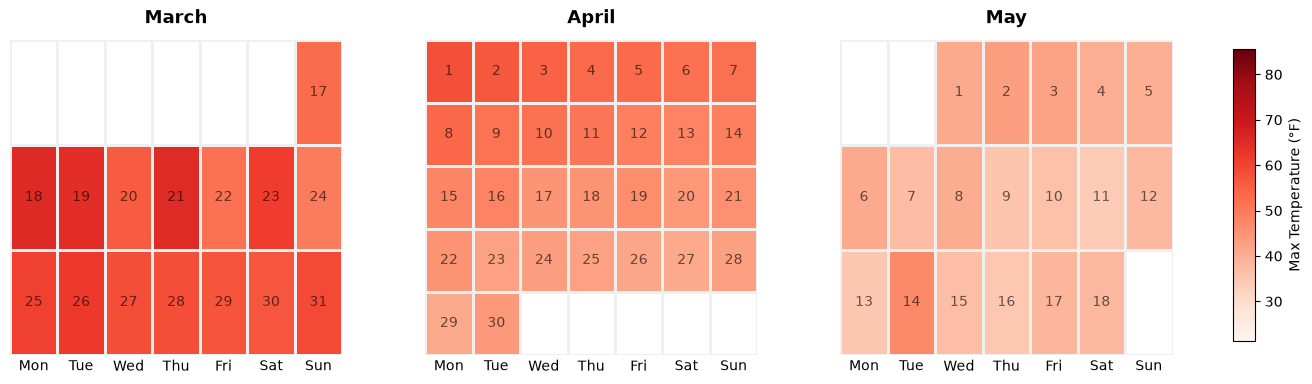

In [13]:
# 1. Extract standard calendar components
df1["month"] = df1["mankai_date"].dt.month
df1["day_name"] = df1["mankai_date"].dt.strftime("%a")
df1["day_of_month"] = df1["mankai_date"].dt.day

# Determine the week number within that month
df1["week_of_month"] = df1["mankai_date"].apply(
    lambda d: (d.day + d.replace(day=1).weekday() - 1) // 7 + 1
)

# FIXED: Filter dataframe to only include March (3), April (4), and May (5)
spring_months = [3, 4, 5]
df1_filtered = df1[df1["month"].isin(spring_months)]

# 2. Define layout structure for only 3 months
month_names = {3: "March", 4: "April", 5: "May"}
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# FIXED: Changed grid setup from 4x3 down to a single row of 3 subplots (1x3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Find global min/max for a consistent color scale across the 3 months
v_min, v_max = df1_filtered["tmax_f"].min(), df1_filtered["tmax_f"].max()

# 3. Plot each spring month individually
for idx, m in enumerate(spring_months):
    ax = axes[idx]
    month_data = df1_filtered[df1_filtered["month"] == m]

    # Check if there is data for this month to avoid empty pivot errors
    if month_data.empty:
        ax.axis("off")
        ax.set_title(month_names[m], fontsize=12, fontweight="bold", pad=10)
        continue

    # Pivot into a Week-of-Month vs Day-of-Week matrix
    month_pivot = month_data.pivot_table(
        index="week_of_month", columns="day_name", values="tmax_f", aggfunc="mean"
    )
    month_pivot = month_pivot.reindex(columns=day_order)

    # Get day numbers to overlay as annotations text
    annot_df = month_data.pivot_table(
        index="week_of_month", columns="day_name", values="day_of_month", aggfunc="first"
    )
    annot_df = annot_df.reindex(columns=day_order)
    
    # Text overlay formatting
    annot_mask = annot_df.map(
        lambda x: f"{int(x)}" if isinstance(x, (int, float)) and not np.isnan(x) else ""
    )

    # Draw individual month heatmap
    sns.heatmap(
        month_pivot,
        cmap="Reds",
        ax=ax,
        cbar=False,
        linewidths=1,
        linecolor="#f0f0f0",
        vmin=v_min,
        vmax=v_max,
        annot=annot_mask.values,
        fmt="",
        annot_kws={"size": 10, "color": "black", "alpha": 0.6},
    )

    # Stylize the month grid
    ax.set_title(month_names[m], fontsize=13, fontweight="bold", pad=12)
    ax.set_xticklabels(day_order, fontsize=10)
    ax.set_yticklabels([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", which="both", length=0)

# Add one global colorbar on the right side
cbar_ax = fig.add_axes([0.94, 0.18, 0.015, 0.65])
sm = plt.cm.ScalarMappable(
    cmap="Reds", norm=plt.Normalize(vmin=v_min, vmax=v_max)
)
fig.colorbar(sm, cax=cbar_ax, label="Max Temperature (°F)")

plt.subplots_adjust(bottom=0.15, top=0.85, wspace=0.25)
plt.show()

The average temperatures seems to be going down as the year progresses. This is not believeable because we are getting closer to summer. A hypothesis, is that the data in March tends to come from Southern Japan, which seems to have a warmer climate than Northern Japan. One way to test this hypothesis, would be to create another map measuring average temperature by location.

In [14]:
# 1. Check if temperature columns are missing from df2
missing_temp_cols = [col for col in ['tavg_f', 'tmin_f', 'tmax_f'] if col not in df2.columns]

if missing_temp_cols:
    print(f"🔄 Merging missing columns {missing_temp_cols} from df_merged onto df2...")
    # Safely merge weather data from your original df_merged using 'code' as the primary key
    # If 'code' isn't available in df_merged, we fallback to 'spot_name'
    merge_key = 'code' if 'code' in df_merged.columns else 'spot_name'
    
    # Isolate only the unique weather tracking data columns we need to add back
    weather_data = df_merged[[merge_key, 'tavg_f', 'tmin_f', 'tmax_f']].drop_duplicates()
    
    # Merge it into a fresh, plotting-ready dataframe
    df_plot_ready = pd.merge(df2, weather_data, on=merge_key, how='left')
else:
    df_plot_ready = df2.copy()

# --- Plotting Setup ---
METRIC = 'tavg_f'  
SAVE_IMG = True

# Drop any row duplicates on coordinates to ensure a clean visualization map
df_map = df_plot_ready.drop_duplicates(subset=['lat', 'lon'])

# Define our hover dataset dynamically based on what columns actually exist now
available_hover = [col for col in ["prefecture", "tmin_f", "tmax_f"] if col in df_map.columns]

# Create scatter map plot
fig = px.scatter_map(
    df_map,
    lat="lat",
    lon="lon",
    color=METRIC if METRIC in df_map.columns else None, # Guard against entirely missing data
    color_continuous_scale="YlOrRd", 
    hover_name="spot_name",
    hover_data=available_hover, 
    zoom=4,
    center={'lat': 38, 'lon': 138},
    height=700,
    map_style="carto-positron" 
)

# Layout styling
fig.update_layout(
    title=dict(
        text="🌡️ Average Temperature (°F) during Sakura Season in Japan",
        x=0.5,
        xanchor='center',
        font=dict(size=20, color='black', family='Arial')
    ),
    paper_bgcolor="white", 
    margin={"r": 0, "t": 60, "l": 0, "b": 0}
)

if SAVE_IMG:
    fig.write_image("sakura_temp_f.png", format='png')

fig.show()

🔄 Merging missing columns ['tavg_f', 'tmin_f', 'tmax_f'] from df_merged onto df2...


The hypothesis was incorrect! The reason why average temperatures drop, is because Cherry Blossoms tend to peak later higher up in the mountains and the higher elevation lends itself to lower average temperatures. While it is true that more southern regions tend to have higher maximum temperatures, they also happen to have greater contrast between high and low temperatures, which tends to push the overall averages down, whereby the temperature differences between the North and the South are not as drastic. Meanwhile contrast between high and low temperatures for the northern regions is significantly lower. Given variations in temperature, due to elevation, it is recommended that visitors bring layers while visiting mountainous areas. Overall, temperatures should be fairly comfortable during this time of year, especially in the south-central regions of Japan.

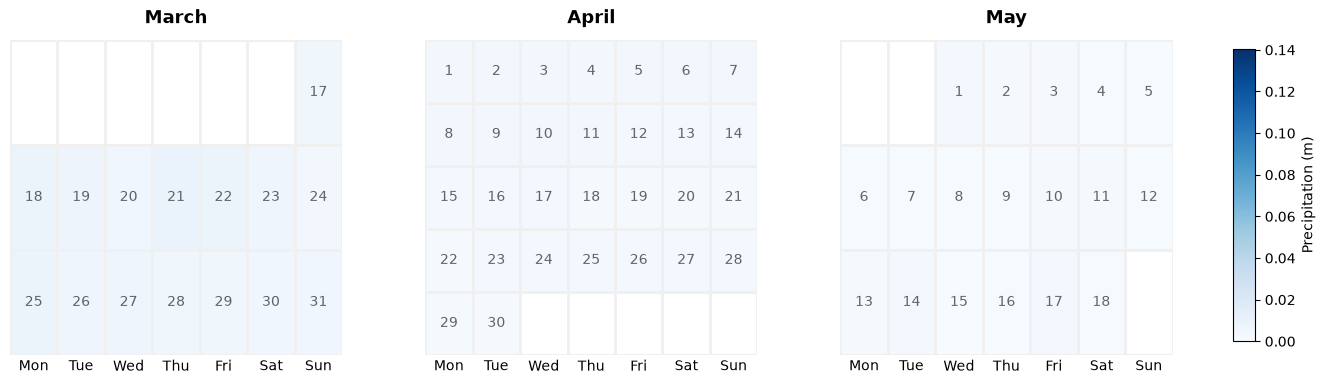

In [15]:
# 1. Extract standard calendar components
df1["month"] = df1["mankai_date"].dt.month
df1["day_name"] = df1["mankai_date"].dt.strftime("%a")
df1["day_of_month"] = df1["mankai_date"].dt.day

# Determine the week number within that month
df1["week_of_month"] = df1["mankai_date"].apply(
    lambda d: (d.day + d.replace(day=1).weekday() - 1) // 7 + 1
)

# FIXED: Filter dataframe to only include March (3), April (4), and May (5)
spring_months = [3, 4, 5]
df1_filtered = df1[df1["month"].isin(spring_months)].copy()

# FIXED: Convert precipitation to meters and assign to 'prcp' instead of 'pcp_m'
df1_filtered["prcp"] = df1_filtered["pcp_in"] / 39.3701

# 2. Define layout structure for only 3 months
month_names = {3: "March", 4: "April", 5: "May"}
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Changed grid setup from 4x3 down to a single row of 3 subplots (1x3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Find global min/max for a consistent color scale across the 3 months (Updated to prcp)
v_min, v_max = df1_filtered["prcp"].min(), df1_filtered["prcp"].max()

# 3. Plot each spring month individually
for idx, m in enumerate(spring_months):
    ax = axes[idx]
    month_data = df1_filtered[df1_filtered["month"] == m]

    # Check if there is data for this month to avoid empty pivot errors
    if month_data.empty:
        ax.axis("off")
        ax.set_title(month_names[m], fontsize=12, fontweight="bold", pad=10)
        continue

    # Pivot into a Week-of-Month vs Day-of-Week matrix (Updated to prcp)
    month_pivot = month_data.pivot_table(
        index="week_of_month", columns="day_name", values="prcp", aggfunc="mean"
    )
    month_pivot = month_pivot.reindex(columns=day_order)

    # Get day numbers to overlay as annotations text
    annot_df = month_data.pivot_table(
        index="week_of_month", columns="day_name", values="day_of_month", aggfunc="first"
    )
    annot_df = annot_df.reindex(columns=day_order)
    
    # Text overlay formatting
    annot_mask = annot_df.map(
        lambda x: f"{int(x)}" if isinstance(x, (int, float)) and not np.isnan(x) else ""
    )

    # Draw individual month heatmap (Blues)
    sns.heatmap(
        month_pivot,
        cmap="Blues",
        ax=ax,
        cbar=False,
        linewidths=1,
        linecolor="#f0f0f0",
        vmin=v_min,
        vmax=v_max,
        annot=annot_mask.values,
        fmt="",
        annot_kws={"size": 10, "color": "black", "alpha": 0.6},
    )

    # Stylize the month grid
    ax.set_title(month_names[m], fontsize=13, fontweight="bold", pad=12)
    ax.set_xticklabels(day_order, fontsize=10)
    ax.set_yticklabels([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", which="both", length=0)

# Add one global colorbar on the right side
cbar_ax = fig.add_axes([0.94, 0.18, 0.015, 0.65])
sm = plt.cm.ScalarMappable(
    cmap="Blues", norm=plt.Normalize(vmin=v_min, vmax=v_max)
)
fig.colorbar(sm, cax=cbar_ax, label="Precipitation (m)")

plt.subplots_adjust(bottom=0.15, top=0.85, wspace=0.25)
plt.show()

It seems like Precipitation levels are constant throughout Cherry Blossom Season at around 0.1-0.2 meters per day. However, these are just averages and there might be differences by region.

In [16]:
# 1. Changed METRIC to 'prcp' (average rainfall)
METRIC = 'prcp'  
SAVE_IMG = True

# FIXED: Passed df_merged (or your respective dataframe name like df2) into the function parameters
df_map = df_for_map(df_merged, last=True)

fig = px.scatter_map(
    df_map,
    lat="lat",
    lon="lon",
    color=METRIC,
    # Changed color_continuous_scale to look like rain (Blues) instead of temperature
    color_continuous_scale="Blues", 
    hover_name="spot_name",
    hover_data=["prefecture"], 
    zoom=4,
    center={'lat': 38, 'lon': 138},
    height=700,
    # FIXED STEP: Map background configuration belongs directly inside the scatter function
    map_style="carto-darkmatter"
)

# 2. Updated the title to reflect average rainfall
fig.update_layout(
    title=dict(
        text="🌧️ Average Rainfall during Sakura Season in Japan",
        x=0.5,
        xanchor='center',
        font=dict(
            size=20,
            color='black',  # Changed back to black
            family='Arial'
        )
    ),
    # Added paper_bgcolor to ensure the title area background stays light/visible for black text
    paper_bgcolor="white", 
    margin={"r":0,"t":60,"l":0,"b":0}
)

# 3. Changed the output image filename to match the new topic
if SAVE_IMG:
    fig.write_image("rainfall.png", format='png')

# Display interactive plot inside your Jupyter environment
fig.show()

There are differences by region in terms of precipitation during Cherry Blossom Season in Japan. Typically, northern regions have higher rainfall during this time of year than southern regions. To minimize rain exposure, it is recommended that tours favor Kyushu and central-southern Honshu to maximize the posibility of viewing the cherry blossoms with clear skies and under ideal temperatures. For the most popular route, Tokyo typically sees more rainfall than Kyoto or Osaka during Cherry Blossom season, so it is recommended that visitors bring raingear for their trip. Alternatively, they can choose to visit Kyushu and the rest of southern Japan for Cherry Blossom season earlier in March to maximize the opportunity of viewing under clear skies.

### Conclusion: ###
It is recommended that the tour footprint be expanded for more adventerous tourists to Kyushu, Shikoku, and other southern regions of Japan. This allows for Cherry Blossom viewing during warmer temperatures with a lower chance of rainfall. However, as popular sites and acommodations are more prevalent in Tokyo, Osaka, and Kyoto, it is still critical to maintain a presence when it comes to tour group offerings for these cities during Cherry Blossom Season.